# Pupil-DLC — General Model (GM) Demo

-> (Do note that for faster inference, use the CLI approach as the Notebook is not using some of the optimization approaches)

Walkthrough with a test video:
1. Run DLC inference with the pre-trained GM
2. Fit ellipses to the detected pupil points
3. Plot pupil radius over time
4. Visualise the fitted ellipse overlaid on sample frames

## 0 — Paths & imports

In [1]:
import os, sys, fnmatch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2

# ── repo root (one level up from this notebook) ──────────────────────────────
REPO_ROOT   = os.path.normpath(os.path.join(os.path.abspath(''), '..'))
sys.path.insert(0, REPO_ROOT)

VIDEO_PATH  = os.path.join(REPO_ROOT, 'Test', 'pupil_test.mp4')
GM_CONFIG   = os.path.join(REPO_ROOT, 'GM_Model', 'config.yaml')
TEST_DIR    = os.path.join(REPO_ROOT, 'Test')
EXPERIMENT  = 'demo'
GPU         = 0          # set to None to use CPU

prefix = os.path.splitext(os.path.basename(VIDEO_PATH))[0]   # 'pupil_test'

print('Video  :', VIDEO_PATH)
print('Config :', GM_CONFIG)
print('Prefix :', prefix)
assert os.path.exists(VIDEO_PATH), 'Test video not found'
assert os.path.exists(GM_CONFIG),  'GM config not found'

Video  : C:\Users\Valyria\Desktop\valyriverse_pupil-dlc\Pupil-DLC\Test\pupil_test.mp4
Config : C:\Users\Valyria\Desktop\valyriverse_pupil-dlc\Pupil-DLC\GM_Model\config.yaml
Prefix : pupil_test


## 1 — DLC inference (GM)

Runs the pre-trained General Model on every frame of the test video.  
Output: a `*DLC*.csv` file saved alongside the video.

In [2]:
import deeplabcut
from pupil_dlc.fast_analyze import patch_dlc_inference

patch_dlc_inference()   # applies speed optimisations

deeplabcut.analyze_videos(
    GM_CONFIG,
    [VIDEO_PATH],
    destfolder=TEST_DIR,   # force output into Test/
    save_as_csv=True,
    allow_growth=True,
    gputouse=GPU,
    batchsize=64
)

# Fallback: if DLC skipped CSV export (existing H5), convert manually
import glob as _glob
h5_files = _glob.glob(os.path.join(TEST_DIR, f'{prefix}*DLC*.h5'))
csv_files = _glob.glob(os.path.join(TEST_DIR, f'{prefix}*DLC*.csv'))
if h5_files and not csv_files:
    for h5 in h5_files:
        csv_out = h5.replace('.h5', '.csv')
        pd.read_hdf(h5).to_csv(csv_out)
        print(f'Converted H5 → CSV: {csv_out}')

print('Files in Test/:')
for f in sorted(os.listdir(TEST_DIR)):
    print(' ', f)
print('Inference complete.')

C:\Users\Valyria\Projects\Anaconda\anaconda3\envs\pupil-dlc-exp\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


Loading DLC 2.2.3...


C:\Users\Valyria\Projects\Anaconda\anaconda3\envs\pupil-dlc-exp\lib\site-packages\deeplabcut\__init__.py:81: UserWarning: 
        As PyTorch is not installed, unsupervised identity learning will not be available.
        Please run `pip install torch`, or ignore this warning.
        
  warnings.warn(
C:\Users\Valyria\Projects\Anaconda\anaconda3\envs\pupil-dlc-exp\lib\site-packages\tensorflow\python\keras\engine\base_layer_v1.py:1694: UserWarning: `layer.apply` is deprecated and will be removed in a future version. Please use `layer.__call__` method instead.
  warnings.warn('`layer.apply` is deprecated and '


Using snapshot-1000000 for model C:\Users\Valyria\Desktop\valyriverse_pupil-dlc\Pupil-DLC\GM_Model\dlc-models\iteration-0\GMNov17-trainset95shuffle1
Starting to analyze %  C:\Users\Valyria\Desktop\valyriverse_pupil-dlc\Pupil-DLC\Test\pupil_test.mp4
Loading  C:\Users\Valyria\Desktop\valyriverse_pupil-dlc\Pupil-DLC\Test\pupil_test.mp4
Duration of video [s]:  61.98 , recorded with  30.01 fps!
Overall # of frames:  1860  found with (before cropping) frame dimensions:  640 480
Starting to extract posture


100%|██████████| 1860/1860 [00:17<00:00, 105.41it/s]


Saving results in C:\Users\Valyria\Desktop\valyriverse_pupil-dlc\Pupil-DLC\Test...
Saving csv poses!
The videos are analyzed. Now your research can truly start! 
 You can create labeled videos with 'create_labeled_video'
If the tracking is not satisfactory for some videos, consider expanding the training set. You can use the function 'extract_outlier_frames' to extract a few representative outlier frames.
Files in Test/:
  .ipynb_checkpoints
  demo_GM.ipynb
  pupil_test.mp4
  pupil_testDLC_resnet50_GMNov17shuffle1_1000000.csv
  pupil_testDLC_resnet50_GMNov17shuffle1_1000000.h5
  pupil_testDLC_resnet50_GMNov17shuffle1_1000000_meta.pickle
Inference complete.


## 2 — Load the DLC CSV

In [3]:
import glob

pattern  = os.path.join(TEST_DIR, f'{prefix}*DLC*.csv')
matches  = glob.glob(pattern)
assert matches, f'No DLC CSV matching {pattern}'

dlc_csv = matches[0]
print('DLC CSV:', dlc_csv)

raw_df = pd.read_csv(dlc_csv, low_memory=False)
print(f'{len(raw_df)} rows  ×  {len(raw_df.columns)} columns')
raw_df.head()

DLC CSV: C:\Users\Valyria\Desktop\valyriverse_pupil-dlc\Pupil-DLC\Test\pupil_testDLC_resnet50_GMNov17shuffle1_1000000.csv
1862 rows  ×  49 columns


,scorer,DLC_resnet50_GMNov17shuffle1_1000000,DLC_resnet50_GMNov17shuffle1_1000000.1,DLC_resnet50_GMNov17shuffle1_1000000.2,DLC_resnet50_GMNov17shuffle1_1000000.3,DLC_resnet50_GMNov17shuffle1_1000000.4,DLC_resnet50_GMNov17shuffle1_1000000.5,DLC_resnet50_GMNov17shuffle1_1000000.6,DLC_resnet50_GMNov17shuffle1_1000000.7,DLC_resnet50_GMNov17shuffle1_1000000.8,...,DLC_resnet50_GMNov17shuffle1_1000000.38,DLC_resnet50_GMNov17shuffle1_1000000.39,DLC_resnet50_GMNov17shuffle1_1000000.40,DLC_resnet50_GMNov17shuffle1_1000000.41,DLC_resnet50_GMNov17shuffle1_1000000.42,DLC_resnet50_GMNov17shuffle1_1000000.43,DLC_resnet50_GMNov17shuffle1_1000000.44,DLC_resnet50_GMNov17shuffle1_1000000.45,DLC_resnet50_GMNov17shuffle1_1000000.46,DLC_resnet50_GMNov17shuffle1_1000000.47
0,bodyparts,Point1,Point1,Point1,Point2,Point2,Point2,Point3,Point3,Point3,...,Eye1,Eye2,Eye2,Eye2,Eye3,Eye3,Eye3,Eye4,Eye4,Eye4
1,coords,x,y,likelihood,x,y,likelihood,x,y,likelihood,...,likelihood,x,y,likelihood,x,y,likelihood,x,y,likelihood
2,0,265.8423156738281,181.0443115234375,0.9997746348381042,287.08978271484375,199.25253295898438,0.9995972514152527,295.5505065917969,224.1671600341797,0.9994661211967468,...,0.9742699861526489,247.15403747558594,365.5262756347656,0.968639612197876,113.18240356445312,245.7864990234375,0.9876937866210938,254.49160766601562,108.04528045654297,0.9974499344825745
3,1,265.7903747558594,180.9566650390625,0.9998040795326233,287.30792236328125,199.25869750976562,0.9994953870773315,295.75030517578125,224.54922485351562,0.9994518160820007,...,0.9755252599716187,244.58908081054688,365.8024597167969,0.9671869874000549,113.38433837890625,245.21302795410156,0.9882038831710815,254.16433715820312,107.80319213867188,0.9973663687705994
4,2,265.8511962890625,180.84469604492188,0.9997977614402771,287.378662109375,198.78836059570312,0.9995356798171997,295.9986877441406,224.2094268798828,0.9994163513183594,...,0.9807146191596985,245.1514434814453,366.44439697265625,0.9627683162689209,113.17160034179688,244.13551330566406,0.9849226474761963,254.2364501953125,108.12203216552734,0.9973886609077454


## 3 — Ellipse fitting

`ellipse_fitting` uses `skimage.measure.EllipseModel` to fit an ellipse to the
detected pupil-boundary points on each frame, requiring ≥ 6 high-confidence
points (likelihood ≥ 0.9).

In [4]:
from pupil_dlc.ellipse import ellipse_fitting
import time

t0 = time.time()
ell_df = ellipse_fitting(raw_df)
print(f'Ellipse fitting: {time.time()-t0:.1f}s')

# Add Euclidean eye diameter (distance between outermost pupil points)
y1 = raw_df.iloc[2:, -5].astype(float)
y0 = raw_df.iloc[2:, -11].astype(float)
x1 = raw_df.iloc[2:, -6].astype(float)
x0 = raw_df.iloc[2:, -12].astype(float)
euc = ((y1 - y0)**2 + (x1 - x0)**2).pow(0.5)
euc.index = ell_df.index
ell_df['Eye_Diameter'] = euc

# Save
out_csv = os.path.join(TEST_DIR, f'PupilEye_{EXPERIMENT}_{prefix}.csv')
ell_df.to_csv(out_csv, index=False)
print('Ellipse CSV saved:', out_csv)
ell_df.head(10)

Ellipse fitting: 0.6s
Ellipse CSV saved: C:\Users\Valyria\Desktop\valyriverse_pupil-dlc\Pupil-DLC\Test\PupilEye_demo_pupil_test.csv


,Time_Frames,X_Position,Y_Position,Radius_1,Radius_2,Angle,Largest_Radius,Eye_Diameter
0,0,246.979185,226.604046,49.349230,48.649158,1.423016,49.349230,351.941465
1,1,246.810120,226.600118,49.558823,48.842441,1.532056,49.558823,351.427229
2,2,247.089874,226.600845,49.552532,48.793382,1.517908,49.552532,348.527267
3,3,247.686232,226.691877,49.669515,49.160034,1.438004,49.669515,346.895746
4,4,247.657299,227.397358,49.848791,49.086110,1.512423,49.848791,346.357694
5,5,249.073646,228.844584,50.409394,49.222028,1.182484,50.409394,352.403781
6,6,249.090946,229.261887,50.168804,48.809022,1.190953,50.168804,356.230256
7,7,247.885120,228.871367,49.965185,48.617818,1.323520,49.965185,354.716365
8,8,248.959787,228.847894,50.072188,48.392050,1.288382,50.072188,352.949032
9,9,248.300919,229.662018,49.725482,48.075431,1.248486,49.725482,353.438103


## 4 — Pupil size over time

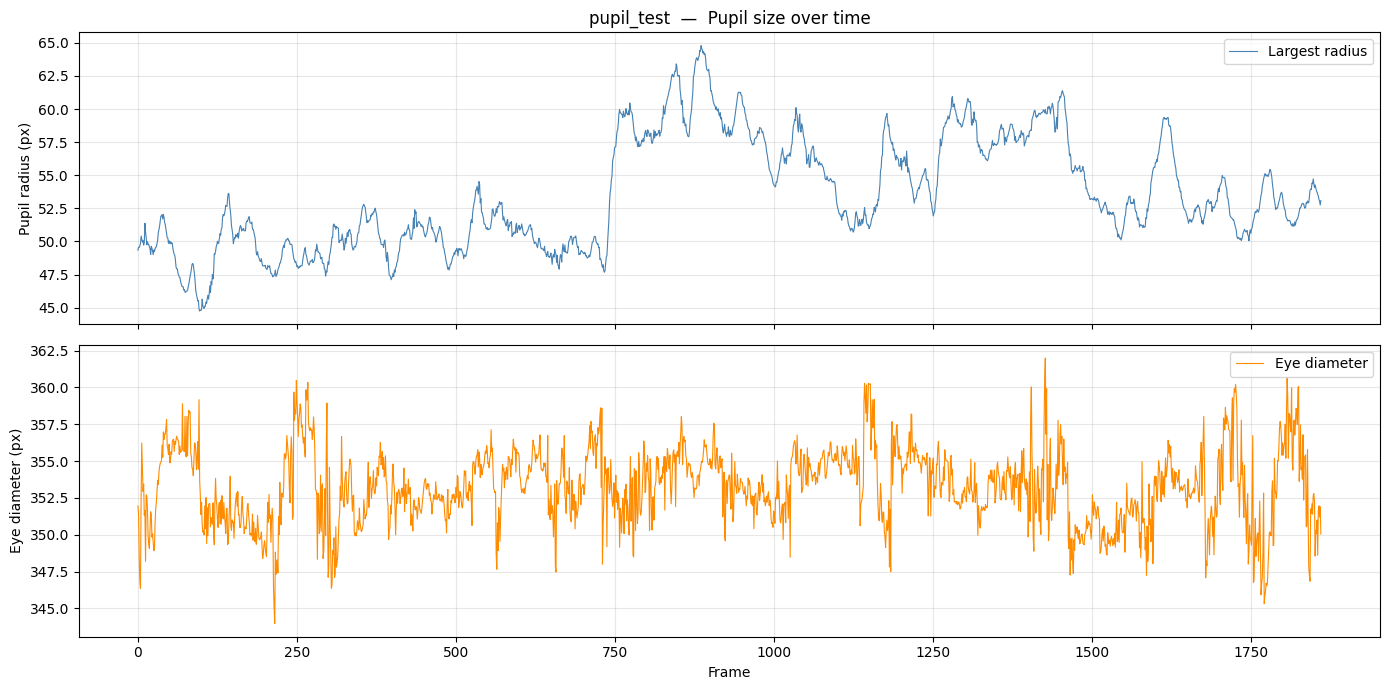

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

valid = ell_df.dropna(subset=['Largest_Radius'])

axes[0].plot(valid['Time_Frames'], valid['Largest_Radius'],
             color='steelblue', linewidth=0.8, label='Largest radius')
axes[0].set_ylabel('Pupil radius (px)')
axes[0].set_title(f'{prefix}  —  Pupil size over time')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(valid['Time_Frames'], valid['Eye_Diameter'],
             color='darkorange', linewidth=0.8, label='Eye diameter')
axes[1].set_xlabel('Frame')
axes[1].set_ylabel('Eye diameter (px)')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
#out_png = os.path.join(TEST_DIR, f'PupilEye_{EXPERIMENT}_{prefix}.png')
#fig.savefig(out_png, dpi=150, bbox_inches='tight')
plt.show()
#print('Plot saved:', out_png)

## 5 — Ellipse overlay on sample frames

Dark-blue ellipse + keypoints drawn on 6 evenly-spaced frames.

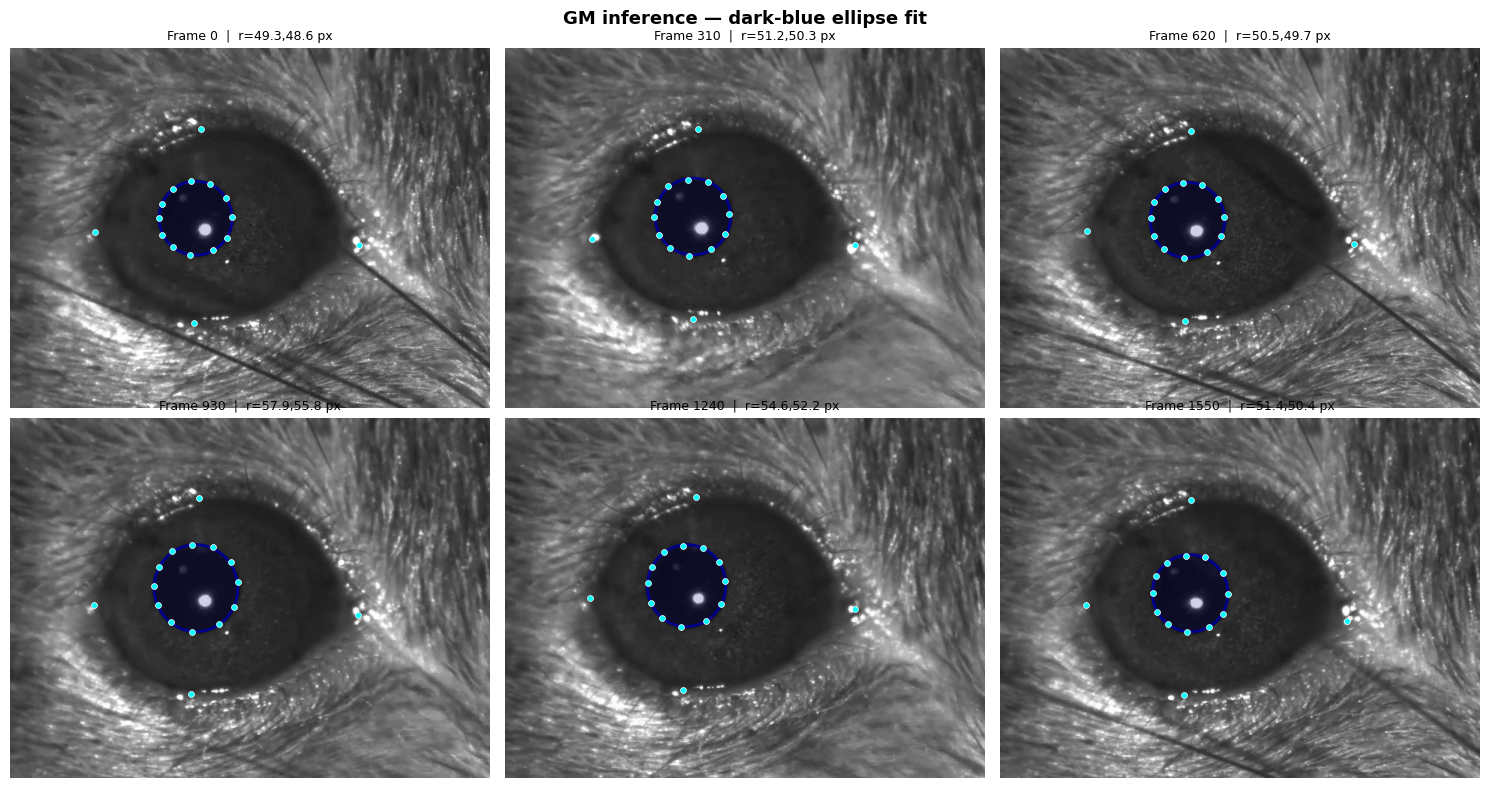

In [7]:
def get_keypoints(raw_df, frame_row):
    """Return (x, y) arrays for all detected points on a given DataFrame row."""
    # DLC CSV: row 0=scorer, 1=bodyparts, 2=coords; data starts at row 3 (index 0 after iloc[3:])
    # raw_df includes those 3 header rows, so data row i is raw_df.iloc[i+3]
    data = raw_df.iloc[3 + frame_row]
    vals = pd.to_numeric(data, errors='coerce').values
    # cols: 0=frame_idx, then triplets (x, y, likelihood) for each bodypart
    xs, ys, liks = vals[1::3], vals[2::3], vals[3::3]
    mask = liks >= 0.9
    return xs[mask], ys[mask]


# Pick 6 frames that have a valid ellipse fit
valid_frames = ell_df.dropna(subset=['X_Position'])['Time_Frames'].values
n_show = min(6, len(valid_frames))
step = max(1, len(valid_frames) // n_show)
sample_frames = valid_frames[::step][:n_show]

cap = cv2.VideoCapture(VIDEO_PATH)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

ELLIPSE_COLOR = 'darkblue'

for ax, frame_idx in zip(axes, sample_frames):
    frame_idx = int(frame_idx)
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ret, frame = cap.read()
    if not ret:
        ax.axis('off')
        continue
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    ax.imshow(frame_rgb, cmap='gray')

    row = ell_df[ell_df['Time_Frames'] == frame_idx].iloc[0]
    cx, cy   = row['X_Position'], row['Y_Position']
    r1, r2   = row['Radius_1'],   row['Radius_2']
    angle_deg = np.degrees(row['Angle'])

    # Dark-blue filled ellipse (low alpha) + dark-blue edge
    ellipse_patch = mpatches.Ellipse(
        (cx, cy),
        width=2 * r1, height=2 * r2,
        angle=angle_deg,
        linewidth=2,
        edgecolor=ELLIPSE_COLOR,
        facecolor=ELLIPSE_COLOR,
        alpha=0.18
    )
    ax.add_patch(ellipse_patch)
    # Solid outline only on top
    outline_patch = mpatches.Ellipse(
        (cx, cy),
        width=2 * r1, height=2 * r2,
        angle=angle_deg,
        linewidth=2,
        edgecolor=ELLIPSE_COLOR,
        facecolor='none'
    )
    ax.add_patch(outline_patch)

    # Keypoints
    try:
        kx, ky = get_keypoints(raw_df, frame_idx)
        ax.scatter(kx, ky, s=18, c='cyan', zorder=5, linewidths=0.5, edgecolors='white')
    except Exception:
        pass

    ax.set_title(f'Frame {frame_idx}  |  r={r1:.1f},{r2:.1f} px', fontsize=9)
    ax.axis('off')

cap.release()
plt.suptitle('GM inference — dark-blue ellipse fit', fontsize=13, fontweight='bold')
plt.tight_layout()
#out_frames = os.path.join(TEST_DIR, f'sample_frames_{prefix}.png')
#fig.savefig(out_frames, dpi=150, bbox_inches='tight')
plt.show()
#print('Frame panel saved:', out_frames)

## 6 — Summary statistics

In [8]:
total   = len(ell_df)
valid_n = ell_df['Largest_Radius'].notna().sum()

print(f'Total frames analysed : {total}')
print(f'Frames with valid fit : {valid_n}  ({100*valid_n/total:.1f}%)')
print()
print(ell_df[['Largest_Radius', 'Eye_Diameter']].describe().round(2))

Total frames analysed : 1860
Frames with valid fit : 1860  (100.0%)

       Largest_Radius  Eye_Diameter
count         1860.00       1860.00
mean            53.53        353.24
std              4.15          2.54
min             44.75        343.98
25%             50.31        351.58
50%             52.51        353.21
75%             57.28        354.97
max             64.79        362.00
